<a href="https://colab.research.google.com/github/hk666890/SEM-VI--A2/blob/main/IPMV_Exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

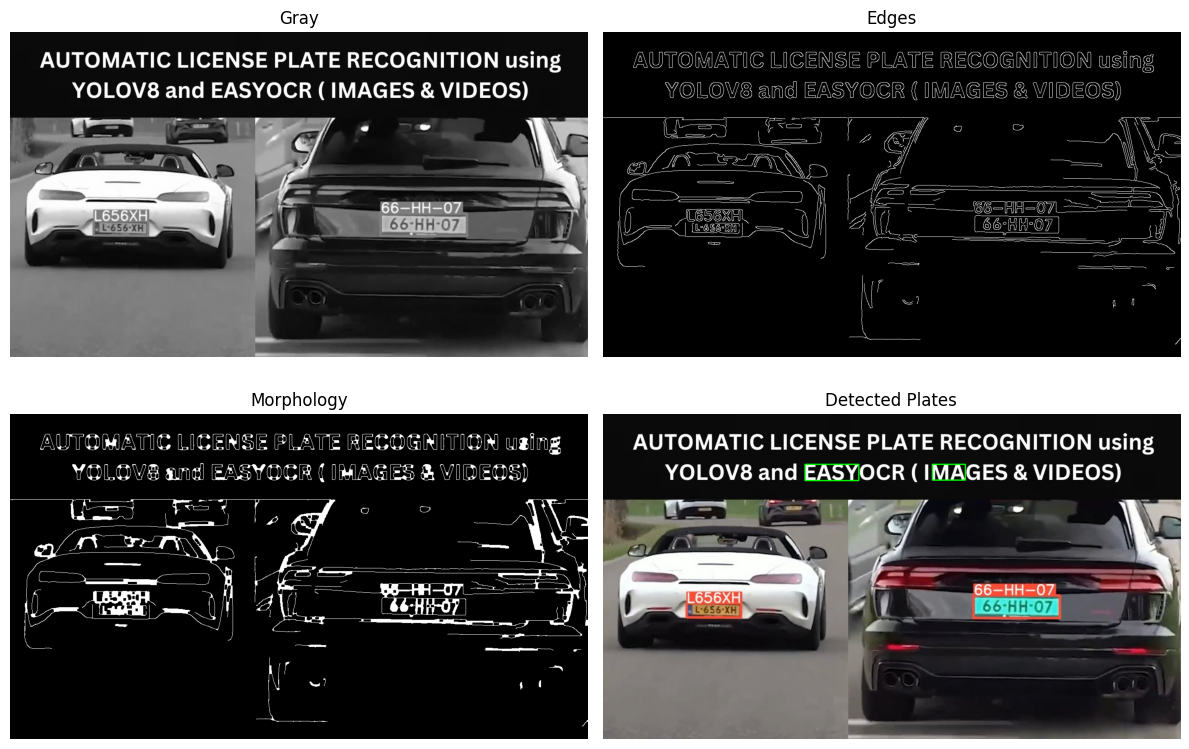

In [ ]:
# STEP 0: Install dependencies
!pip install opencv-python matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt

def case_study_license_plate(image_path):
    # --------------------------------------------------------
    # STEP 1: Load and preprocess image
    # --------------------------------------------------------
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # --------------------------------------------------------
    # STEP 2: Edge Detection
    # --------------------------------------------------------
    edges = cv2.Canny(blurred, 100, 200)

    # --------------------------------------------------------
    # STEP 3: Morphological Operations
    # --------------------------------------------------------
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # --------------------------------------------------------
    # STEP 4: Contour Detection
    # --------------------------------------------------------
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    plate_candidates = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        if 2 < aspect_ratio < 6 and 1000 < cv2.contourArea(cnt) < 15000:
            plate_candidates.append((x, y, w, h))
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # --------------------------------------------------------
    # STEP 5: Display Results
    # --------------------------------------------------------
    titles = ["Gray", "Edges", "Morphology", "Detected Plates"]
    images = [gray, edges, morph, cv2.cvtColor(img, cv2.COLOR_BGR2RGB)]

    plt.figure(figsize=(12, 8))
    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.imshow(images[i], cmap='gray' if i < 3 else None)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage (upload your own car image in Colab)
case_study_license_plate("car.jpg")